In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
x, y= make_classification(n_features=5,n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(x, columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.396764,0.370508,0.040585,2.358435,-0.286899,0
1,1.078273,-0.139041,1.032688,-2.119485,-0.027468,1
2,2.445642,-0.404090,1.781007,-3.199010,0.849652,1
3,1.658460,0.248311,0.577004,-1.628243,0.070051,1
4,-0.441703,0.997176,-2.303104,-0.188887,1.801427,1


In [4]:
# function for row sampling

def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]), replace=True)

In [6]:
# function for feature sampling

def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [7]:
# function for combined sampling

def combined_sampling(df, row_percent, col_percent):
  new_df = sample_rows(df, row_percent)
  return sample_features(new_df, col_percent)

In [8]:
df1 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_803/3325536371.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [9]:
df2 = combined_sampling(df,0.5, 0.5)

/tmp/ipykernel_803/3325536371.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [10]:
df3 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_803/3325536371.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [11]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col2', 'target'], dtype='object')
Index(['col3', 'col4', 'target'], dtype='object')
Index(['col3', 'col1', 'target'], dtype='object')


In [12]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [13]:
clf1.fit(df1.iloc[:,0:2], df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [14]:
from sklearn.tree import plot_tree

[Text(0.2727272727272727, 0.9285714285714286, 'x[1] <= -0.362\ngini = 0.48\nsamples = 50\nvalue = [20, 30]'),
 Text(0.18181818181818182, 0.7857142857142857, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.22727272727272727, 0.8571428571428572, 'True  '),
 Text(0.36363636363636365, 0.7857142857142857, 'x[0] <= -1.379\ngini = 0.208\nsamples = 34\nvalue = [4, 30]'),
 Text(0.3181818181818182, 0.8571428571428572, '  False'),
 Text(0.18181818181818182, 0.6428571428571429, 'x[0] <= -1.705\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.09090909090909091, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.2727272727272727, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5454545454545454, 0.6428571428571429, 'x[0] <= -0.061\ngini = 0.128\nsamples = 29\nvalue = [2, 27]'),
 Text(0.45454545454545453, 0.5, 'gini = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.6363636363636364, 0.5, 'x[0] <= 0.045\ngini = 0.346\nsamples = 9\nvalue = [2, 7]'),
 Text(0.5454545454545454, 0.357

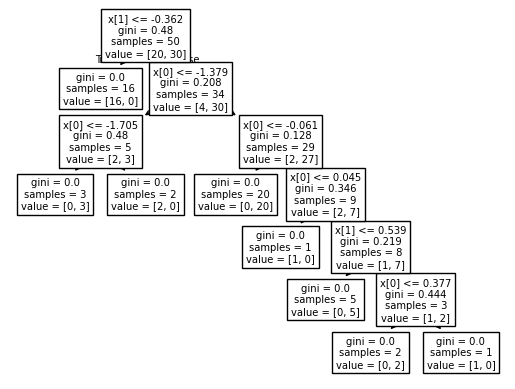

In [15]:
plot_tree(clf1)

[Text(0.6666666666666666, 0.875, 'x[1] <= 0.154\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.5, 0.625, 'x[0] <= -1.744\ngini = 0.367\nsamples = 33\nvalue = [8, 25]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'x[1] <= -0.894\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 23\nvalue = [0, 23]'),
 Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.75, 0.75, '  False')]

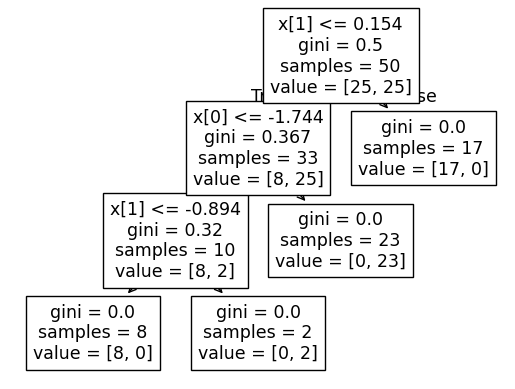

In [16]:
plot_tree(clf2)

[Text(0.3333333333333333, 0.9, 'x[1] <= -0.751\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.16666666666666666, 0.7, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]'),
 Text(0.25, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[0] <= -2.298\ngini = 0.225\nsamples = 31\nvalue = [4, 27]'),
 Text(0.41666666666666663, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6666666666666666, 0.5, 'x[1] <= -0.205\ngini = 0.069\nsamples = 28\nvalue = [1, 27]'),
 Text(0.5, 0.3, 'x[1] <= -0.279\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8333333333333334, 0.3, 'gini = 0.0\nsamples = 23\nvalue = [0, 23]')]

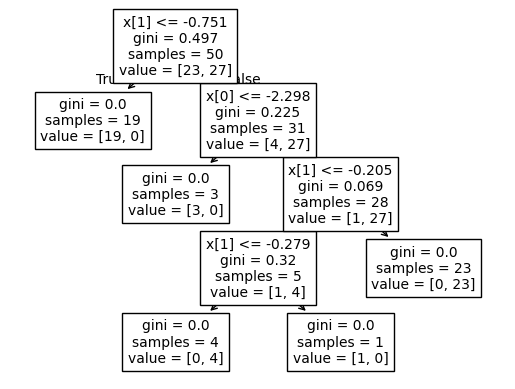

In [17]:
plot_tree(clf3)

In [18]:
df.sample(14)

,col1,col2,col3,col4,col5,target
19,-0.788590,1.157611,0.263938,2.437382,1.515495,0
73,-0.962332,-2.505586,-2.404118,-1.125288,1.558321,0
62,0.180156,-1.101139,-2.512925,-1.935789,-0.437538,0
7,0.652688,1.432621,-1.960359,0.134321,0.939208,1
37,1.460010,1.100745,0.278874,-3.129779,0.634858,1
30,1.069779,0.264203,-0.106894,-1.235170,0.689443,1
17,-1.982035,-1.615230,-1.021791,1.954621,1.049552,0
66,1.017903,1.762350,-2.082123,-0.241274,1.182466,1
61,0.076414,-0.816466,-2.251716,-0.314104,1.344100,0
41,0.845705,1.139874,-0.853702,-0.755769,0.147710,1


In [22]:
clf1.predict(np.array([-0.788590 ,	1.157611	]).reshape(1,2))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [23]:
clf2.predict(np.array([-0.788590 ,	1.157611	]).reshape(1,2))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [24]:
clf3.predict(np.array([-0.788590 ,	1.157611	]).reshape(1,2))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])